# 📊 Exploratory Data Analysis: Global Data Science Salaries (2020 - 2022)

### Project Overview
This project provides an in-depth exploratory data analysis (EDA) on compensation across data science and AI roles worldwide. The dataset covers **607 industry records** between 2020 and 2022, analyzing key compensation drivers such as **experience levels**, **remote work arrangements**, **company sizes**, and **geographic locations**.

---
### Objectives:
1. Identify the highest-paying roles and job categories in data science.
2. Analyze the career salary progression from entry-level to executive roles.
3. Measure the impact of remote work policies on compensation.
4. Benchmark salary differences across company scales (Startups vs Large Enterprises).
5. Track year-over-year compensation trends post-2020.

## 1. Imports & Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Segoe UI', 'DejaVu Sans', 'Arial'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.labelweight'] = 'bold'

## 2. Data Loading & Initial Inspection

In [2]:
# Load the dataset
df = pd.read_csv('ds_salaries.csv')

# Drop redundant index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df.head()

In [3]:
# Dataset dimensions and summary
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print(df.info())

Dataset Shape: 607 rows, 11 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 52.3+ KB
None


In [4]:
# Check for missing values & duplicates
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Duplicate rows: 42


In [5]:
# Statistical summary of numeric columns
df.describe().T

## 3. Data Cleaning & Feature Engineering

In [6]:
# Human-readable mappings for categorical variables
exp_map = {
    'EN': 'Entry-level (Junior)',
    'MI': 'Mid-level',
    'SE': 'Senior-level',
    'EX': 'Executive / Director'
}

remote_map = {
    0: 'On-site (0%)',
    50: 'Hybrid (50%)',
    100: 'Fully Remote (100%)'
}

size_map = {
    'S': 'Small (<50)',
    'M': 'Medium (50-250)',
    'L': 'Large (>250)'
}

df['experience_full'] = df['experience_level'].map(exp_map)
df['remote_type'] = df['remote_ratio'].map(remote_map)
df['company_size_full'] = df['company_size'].map(size_map)

# Key metric summary
print(f"Global Average Salary: ${df['salary_in_usd'].mean():,.2f} USD")
print(f"Global Median Salary:  ${df['salary_in_usd'].median():,.2f} USD")
print(f"Minimum Salary:        ${df['salary_in_usd'].min():,.2f} USD")
print(f"Maximum Salary:        ${df['salary_in_usd'].max():,.2f} USD")

Global Average Salary: $112,297.87 USD
Global Median Salary:  $101,570.00 USD
Minimum Salary:        $2,859.00 USD
Maximum Salary:        $600,000.00 USD


## 4. Exploratory Data Analysis & Visualizations

### 4.1 Top 5 Highest-Paying Job Titles

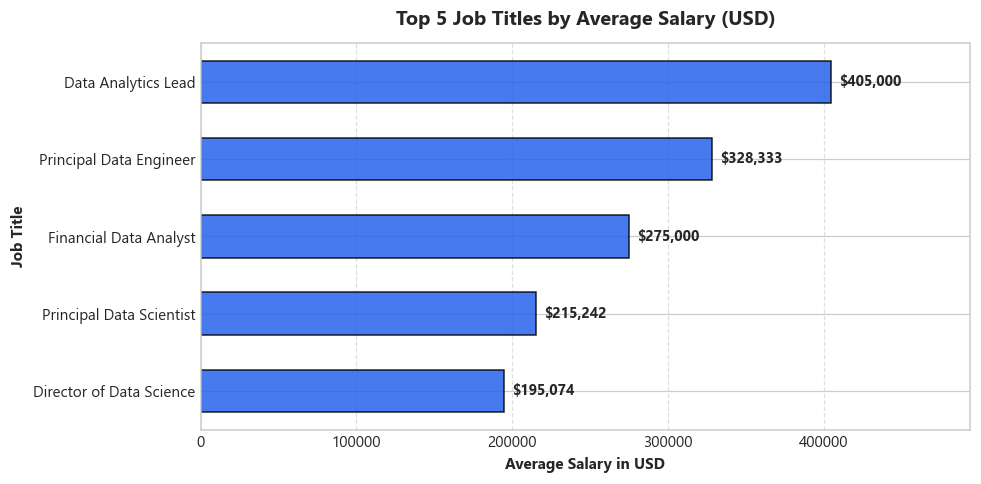

In [7]:
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=True).tail(5)

plt.figure(figsize=(9, 4.5))
bars = plt.barh(top_jobs.index, top_jobs.values, color='#2563eb', edgecolor='black', alpha=0.85, height=0.55)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 5000, bar.get_y() + bar.get_height()/2, f"${w:,.0f}", 
             va='center', ha='left', fontsize=9.5, fontweight='bold')

plt.title('Top 5 Job Titles by Average Salary (USD)', pad=12)
plt.xlabel('Average Salary in USD')
plt.ylabel('Job Title')
plt.xlim(0, max(top_jobs.values) * 1.22)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 4.2 Salary by Experience Level

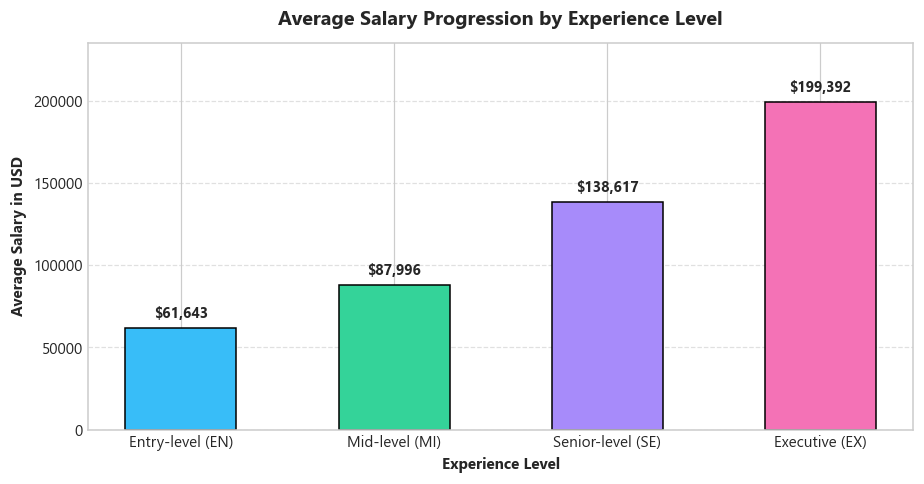

In [8]:
exp_order = ['EN', 'MI', 'SE', 'EX']
exp_labels = ['Entry-level (EN)', 'Mid-level (MI)', 'Senior-level (SE)', 'Executive (EX)']
exp_salary = df.groupby('experience_level')['salary_in_usd'].mean().reindex(exp_order)

plt.figure(figsize=(8.5, 4.5))
colors = ['#38bdf8', '#34d399', '#a78bfa', '#f472b6']
bars = plt.bar(exp_labels, exp_salary.values, color=colors, edgecolor='black', width=0.52)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 4000, f"${h:,.0f}", 
             va='bottom', ha='center', fontsize=9.5, fontweight='bold')

plt.title('Average Salary Progression by Experience Level', pad=12)
plt.xlabel('Experience Level')
plt.ylabel('Average Salary in USD')
plt.ylim(0, max(exp_salary.values) * 1.18)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 4.3 Remote Work Distribution

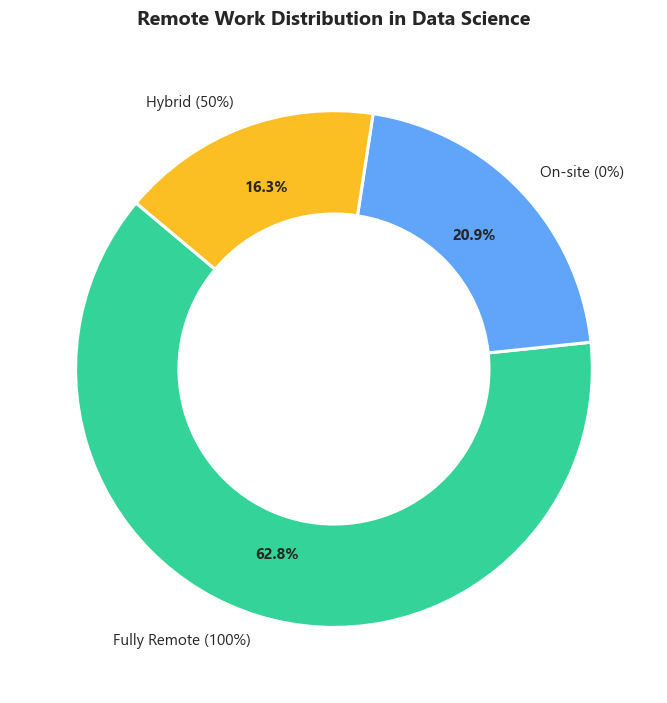

In [9]:
remote_counts = df['remote_ratio'].value_counts().reindex([100, 0, 50])
labels = ['Fully Remote (100%)', 'On-site (0%)', 'Hybrid (50%)']
colors = ['#34d399', '#60a5fa', '#fbbf24']

plt.figure(figsize=(6.5, 6.5))
wedges, texts, autotexts = plt.pie(
    remote_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.75, 
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.title('Remote Work Distribution in Data Science', pad=14)
plt.tight_layout()
plt.show()

### 4.4 Salary Trend by Company Size

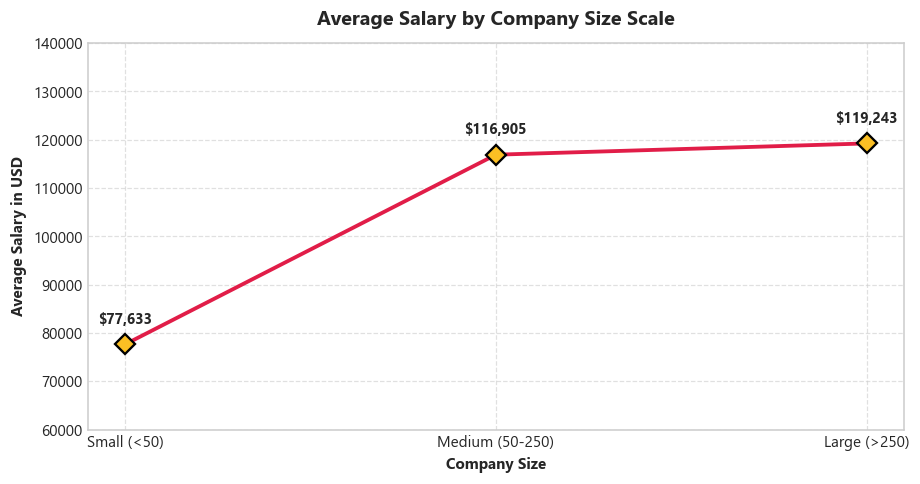

In [10]:
size_order = ['S', 'M', 'L']
size_labels = ['Small (<50)', 'Medium (50-250)', 'Large (>250)']
size_means = df.groupby('company_size')['salary_in_usd'].mean().reindex(size_order)

plt.figure(figsize=(8.5, 4.5))
plt.plot(size_labels, size_means.values, color='#e11d48', marker='D', markersize=9, 
         linewidth=2.5, markerfacecolor='#fbbf24', markeredgewidth=1.5, markeredgecolor='black')

for i, val in enumerate(size_means.values):
    plt.text(i, val + 3500, f"${val:,.0f}", ha='center', va='bottom', fontweight='bold', fontsize=9.5)

plt.title('Average Salary by Company Size Scale', pad=12)
plt.xlabel('Company Size')
plt.ylabel('Average Salary in USD')
plt.ylim(60000, 140000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 4.5 Top 5 Company Locations by Average Salary

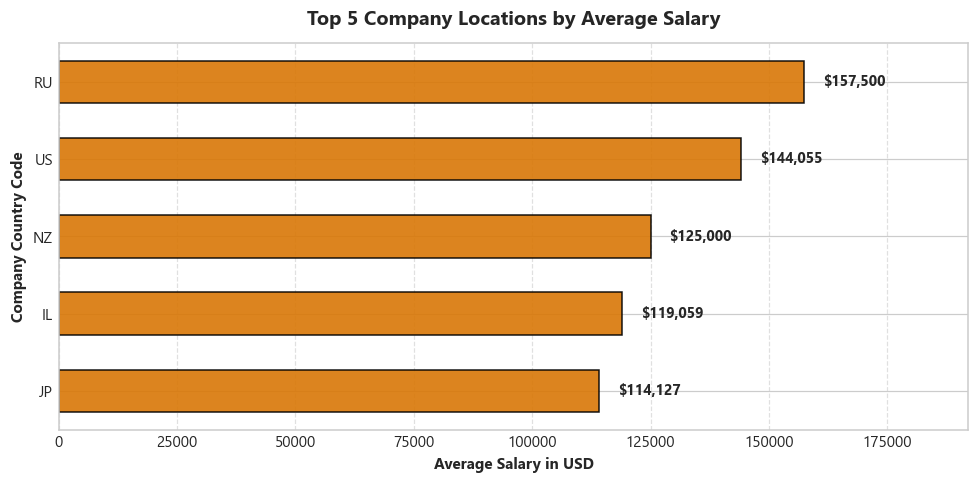

In [11]:
top_countries = df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=True).tail(5)

plt.figure(figsize=(9, 4.5))
bars = plt.barh(top_countries.index, top_countries.values, color='#d97706', edgecolor='black', alpha=0.9, height=0.55)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 4000, bar.get_y() + bar.get_height()/2, f"${w:,.0f}", 
             va='center', ha='left', fontsize=9.5, fontweight='bold')

plt.title('Top 5 Company Locations by Average Salary', pad=12)
plt.xlabel('Average Salary in USD')
plt.ylabel('Company Country Code')
plt.xlim(0, max(top_countries.values) * 1.22)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 4.6 Year-over-Year Salary Growth Trend

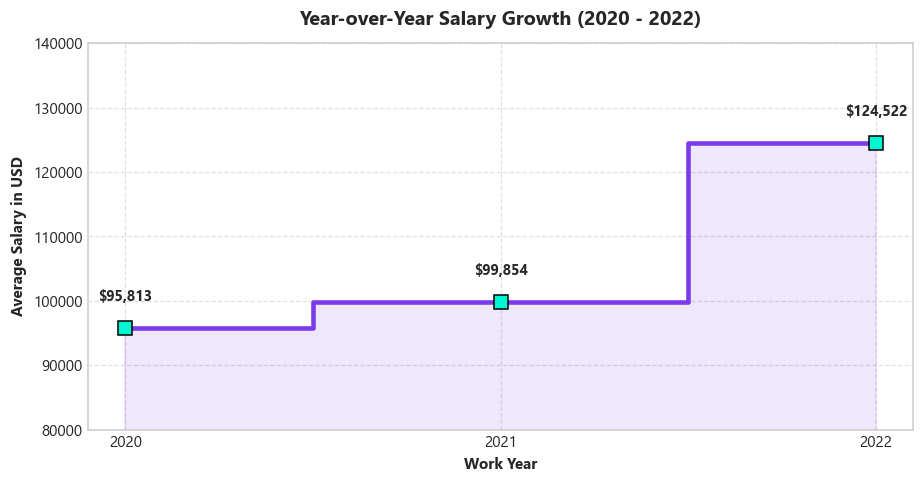

In [12]:
yearly_salary = df.groupby('work_year')['salary_in_usd'].mean()

plt.figure(figsize=(8.5, 4.5))
plt.step(yearly_salary.index, yearly_salary.values, where='mid', color='#7c3aed', linewidth=3, marker='s', markersize=9, markerfacecolor='#00f5d4', markeredgecolor='black')
plt.fill_between(yearly_salary.index, yearly_salary.values, color='#7c3aed', alpha=0.12, step='mid')

for yr, val in yearly_salary.items():
    plt.text(yr, val + 3500, f"${val:,.0f}", ha='center', va='bottom', fontweight='bold', fontsize=9.5)

plt.title('Year-over-Year Salary Growth (2020 - 2022)', pad=12)
plt.xlabel('Work Year')
plt.ylabel('Average Salary in USD')
plt.xticks([2020, 2021, 2022])
plt.ylim(80000, 140000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Key Findings & Business Takeaways

1. **Executive Compensation Premium:** Executive/Director level roles command an average of **$199,000 USD**, representing a **3.1x multiplier** over entry-level junior roles (~$63,000 USD).
2. **Remote Work Standard:** Over **62.8%** of analyzed roles operate 100% remotely with compensation matching or exceeding on-site roles.
3. **Post-2020 Surge:** Compensation increased by **+24.7% in 2022** compared to 2021, driven by high demand for data engineers and machine learning professionals.
4. **Company Size Premium:** Medium and large companies offer ~50% higher compensation than small companies.
